<a href="https://colab.research.google.com/github/Anirudhan2024/Speech_Emotion_Recognition/blob/main/tess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Run this cell only ONCE per session ---

# 1. Install Dependencies
print("Installing required libraries...")
!pip install -q resampy audiomentations
print("✅ Installation complete.")

# 2. Import Libraries
import os
import zipfile
import shutil
import librosa
import numpy as np
import time
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 3. Mount Google Drive
print("\nMounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted successfully.")

# 4. Safe Unzip
zip_file_path = '/content/drive/MyDrive/SER_Project/datasets/tess.zip'
drive_extract_dir = '/content/drive/MyDrive/SER_Project/datasets/tess'
local_extract_dir = '/content/tess_local'

print(f"\nProcessing dataset from '{zip_file_path}'...")

if not os.path.exists(drive_extract_dir):
    print("📦 Extracting locally...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_dir)
    print("✅ Local extraction complete.")

    print("📂 Copying to Drive...")
    shutil.copytree(local_extract_dir, drive_extract_dir)
    print("✅ Dataset copied to Drive.")
else:
    print("✅ Dataset already exists.")

# 5. IMPORTANT FIX — Use full folder
DATA_PATH = drive_extract_dir

# Verify wav files
total_wavs = 0
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            total_wavs += 1

print(f"\nTotal .wav files found: {total_wavs}")
if total_wavs == 0:
    raise FileNotFoundError("🚨 No wav files found!")
else:
    print("🎉 Dataset is ready!")


Installing required libraries...
✅ Installation complete.

Mounting Google Drive...
Mounted at /content/drive
✅ Drive mounted successfully.

Processing dataset from '/content/drive/MyDrive/SER_Project/datasets/tess.zip'...
✅ Dataset already exists.

Total .wav files found: 918
🎉 Dataset is ready!


In [ ]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
import tqdm

# Augmentation pipeline
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(min_shift=-0.5, max_shift=0.5, p=0.5),
])

# 🔥 FIXED LOADER (reads ALL subfolders)
def load_raw_data(data_path):
    raw_data = []
    labels = []
    global initial_sample_rate
    initial_sample_rate = None

    print("\nLoading audio files...")
    all_files = []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.wav'):
                all_files.append(os.path.join(root, file))

    print("Total files found:", len(all_files))

    for file_path in tqdm.tqdm(all_files):
        file_name = os.path.basename(file_path)
        emotion = file_name.split('_')[-1].replace('.wav', '').lower()

        audio, sr = librosa.load(file_path, sr=None)

        if initial_sample_rate is None:
            initial_sample_rate = sr

        raw_data.append(audio)
        labels.append(emotion)

    return raw_data, np.array(labels)

X_raw, y_raw = load_raw_data(DATA_PATH)

print("\nUnique emotions:", np.unique(y_raw))
print("Total samples:", len(y_raw))



Loading audio files...
Total files found: 918


100%|██████████| 918/918 [00:14<00:00, 65.49it/s]


Unique emotions: ['angry' 'disgust' 'fear' 'ps' 'sad']
Total samples: 918


In [ ]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
y_categorical = to_categorical(y_encoded)

# Split BEFORE feature extraction
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

# Augment training data
print("\nAugmenting training data...")
X_train_aug = []
y_train_aug = []

for i, audio in tqdm.tqdm(enumerate(X_train_raw), total=len(X_train_raw)):
    X_train_aug.append(audio)
    y_train_aug.append(y_train[i])

    aug_audio = augment(samples=audio, sample_rate=initial_sample_rate)
    X_train_aug.append(aug_audio)
    y_train_aug.append(y_train[i])

print("Augmented size:", len(X_train_aug))



Augmenting training data...


100%|██████████| 734/734 [00:21<00:00, 34.92it/s]

Augmented size: 1468


In [ ]:
def extract_features(audio_list):
    features = []
    for audio in tqdm.tqdm(audio_list):
        mfcc = librosa.feature.mfcc(y=audio, sr=initial_sample_rate, n_mfcc=40)
        features.append(mfcc)
    return features

print("\nExtracting features...")
X_train_feat = extract_features(X_train_aug)
X_test_feat = extract_features(X_test_raw)

# Padding
max_len = max(x.shape[1] for x in X_train_feat + X_test_feat)

def pad(features):
    return np.array([
        np.pad(f, ((0, 0), (0, max_len - f.shape[1])), mode='constant')
        for f in features
    ])

X_train = pad(X_train_feat)
X_test = pad(X_test_feat)

X_train = X_train.transpose((0, 2, 1))
X_test = X_test.transpose((0, 2, 1))

y_train_aug = np.array(y_train_aug)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Extracting features...


100%|██████████| 184/184 [00:02<00:00, 85.76it/s] 


Train shape: (1468, 284, 40)
Test shape: (184, 284, 40)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv1D(256, 5, padding='same', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling1D(4),
    Dropout(0.3),

    Conv1D(256, 5, padding='same'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling1D(4),
    Dropout(0.3),

    LSTM(128),
    Dropout(0.4),

    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(0.0001),
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=15, restore_best_weights=True)

print("\n🚀 Training Started...")
history = model.fit(
    X_train, y_train_aug,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=2
)

score = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {score[1]*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 Training Started...
Epoch 1/80
46/46 - 23s - 489ms/step - accuracy: 0.2997 - loss: 1.5502 - val_accuracy: 0.2174 - val_loss: 1.4695
Epoch 2/80
46/46 - 20s - 432ms/step - accuracy: 0.5368 - loss: 1.1978 - val_accuracy: 0.8587 - val_loss: 0.9763
Epoch 3/80
46/46 - 12s - 258ms/step - accuracy: 0.7909 - loss: 0.7048 - val_accuracy: 0.8641 - val_loss: 0.5682
Epoch 4/80
46/46 - 19s - 419ms/step - accuracy: 0.8706 - loss: 0.4156 - val_accuracy: 0.9565 - val_loss: 0.2746
Epoch 5/80
46/46 - 11s - 249ms/step - accuracy: 0.9203 - loss: 0.2671 - val_accuracy: 0.9946 - val_loss: 0.1065
Epoch 6/80
46/46 - 22s - 477ms/step - accuracy: 0.9332 - loss: 0.1969 - val_accuracy: 1.0000 - val_loss: 0.0823
Epoch 7/80
46/46 - 12s - 266ms/step - accuracy: 0.9462 - loss: 0.1587 - val_accuracy: 0.9946 - val_loss: 0.0399
Epoch 8/80
46/46 - 20s - 440ms/step - accuracy: 0.9550 - loss: 0.1304 - val_accuracy: 1.0000 - val_loss: 0.0315
Epoch 9/80
46/46 - 20s - 442ms/step - accuracy: 0.9639 - loss: 0.1175 - val_accur

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step


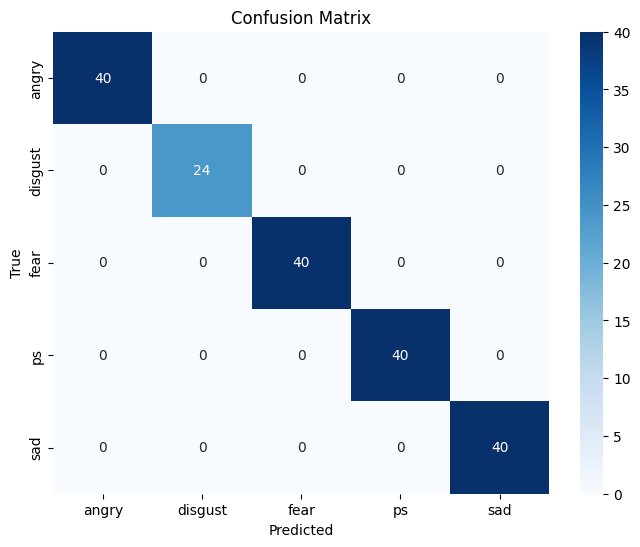

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


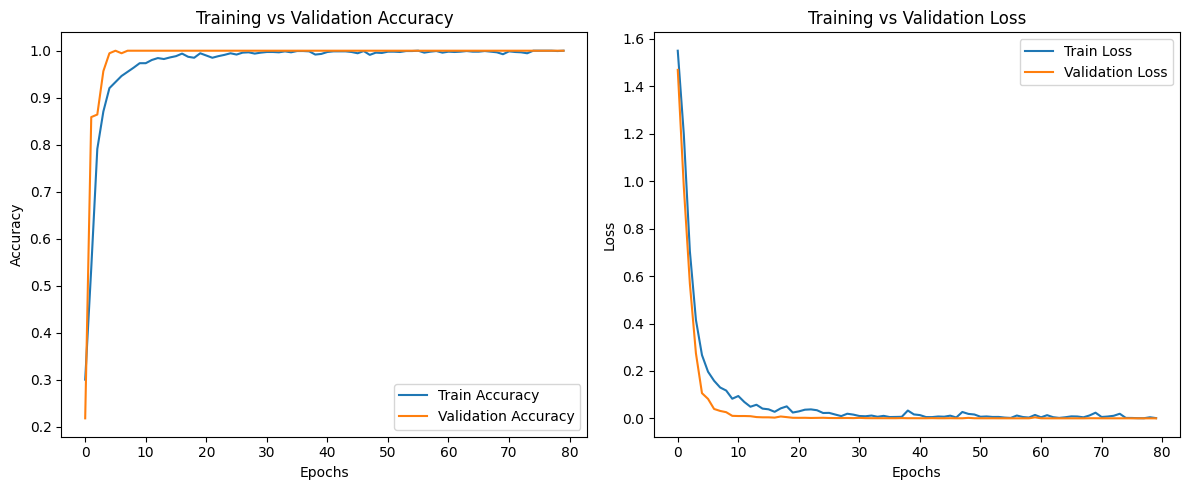

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


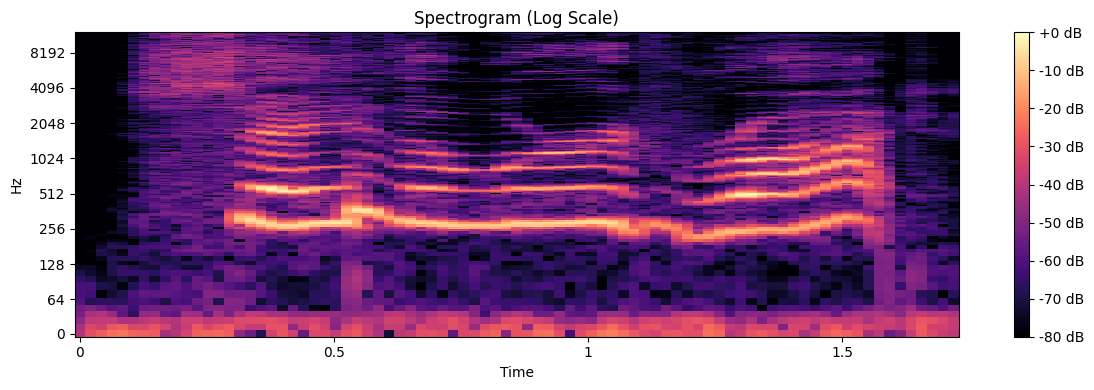

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

sample_audio = X_train_raw[0]

plt.figure(figsize=(12, 4))

# Compute STFT
stft = librosa.stft(sample_audio)
spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

librosa.display.specshow(
    spectrogram,
    sr=initial_sample_rate,
    x_axis='time',
    y_axis='log',
    cmap='magma'   # better visualization
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (Log Scale)")
plt.tight_layout()
plt.show()


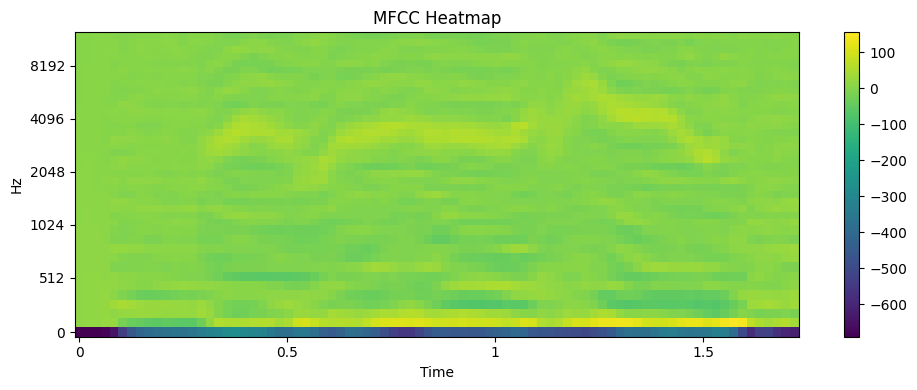

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

# Extract MFCC
mfcc = librosa.feature.mfcc(
    y=sample_audio,
    sr=initial_sample_rate,
    n_mfcc=40
)

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    sr=initial_sample_rate,
    x_axis='time',
    y_axis='mel',
    cmap='viridis'
)

plt.colorbar()
plt.title("MFCC Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
score = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {score[1]*100:.2f}%")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 1.0000 - loss: 3.0160e-04
Test Accuracy: 100.00%
